# SDE methods practice

하나의 2차원 확률미분방정식(SDE)을 기준으로 수치해석, Fokker–Planck PINN, Neural SDE, 강화학습을 비교합니다.

상태공간은 $X=\mathbb{R}^2$이고 상태는 $x_t=(q_t,v_t)\in X$입니다.

사용하는 SDE는

$$
dq_t=v_t\,dt,
$$

$$
dv_t=(-kq_t-cv_t)\,dt+\sigma\,dW_t
$$

입니다. 여기서 $W_t:\Omega\times[0,T]\to\mathbb{R}$는 1차원 Wiener process, $k>0$는 spring 계수, $c>0$는 damping 계수, $\sigma\ge0$는 noise 크기입니다.

목적은 같은 확률 동역학을 네 가지 관점으로 보는 것입니다.

1. Euler–Maruyama: 주어진 SDE에서 샘플 경로를 직접 생성
2. Fokker–Planck PINN: 경로가 아니라 확률밀도 $\rho:[0,T]\times\mathbb{R}^2\to\mathbb{R}_{\ge0}$를 학습
3. Neural SDE: drift와 diffusion을 신경망으로 학습
4. RL: noise가 있는 환경에서 제어정책 $\pi_\theta$를 학습


In [1]:
!git clone -q https://github.com/HisameOgasahara/RL_tmp.git
%cd RL_tmp
!pip install -q -r requirements.txt
import sys
sys.path.append("src")


/content/RL_tmp


## 1. 공통 설정

$T>0$는 최종 시간, $\Delta t>0$는 시간 간격입니다. 초기 상태 $x_0=(q_0,v_0)$에서 시작합니다.


In [2]:
import torch

from rl_tmp.sde_methods.sde_system import SDEOscillatorConfig
from rl_tmp.sde_methods.sde_solver import make_sde_reference_dataset, solve_sde_reference
from rl_tmp.sde_methods.sde_visualize import (
    plot_density,
    plot_loss,
    plot_neural_sde_comparison,
    plot_phase_samples,
    plot_sample_paths,
    plot_sde_rl_rollout,
)

device = "cuda" if torch.cuda.is_available() else "cpu"

spring = 1.0
damping = 0.3
noise = 0.35
t_final = 8.0
dt = 0.05

initial_q = 1.5
initial_v = 0.0

config = SDEOscillatorConfig(
    spring=spring,
    damping=damping,
    noise=noise,
)

times = torch.arange(0.0, t_final + 1e-9, dt)
initial_state = torch.tensor([initial_q, initial_v], dtype=torch.float32)

print("device:", device)
print("time steps:", len(times))


device: cpu
time steps: 161


## 2. Euler–Maruyama

Euler–Maruyama는 SDE

$$
dX_t=b(X_t)\,dt+\sigma(X_t)\,dW_t
$$

를 작은 시간 간격에서

$$
X_{n+1}=X_n+b(X_n)\Delta t+\sigma(X_n)\sqrt{\Delta t}\,\xi_n
$$

으로 근사합니다. 여기서 $\xi_n\sim\mathcal{N}(0,I)$입니다.

ODE의 RK4가 하나의 결정론적 궤적을 만드는 것과 달리, SDE에서는 같은 초기값에서도 noise에 따라 여러 샘플 경로가 나옵니다.


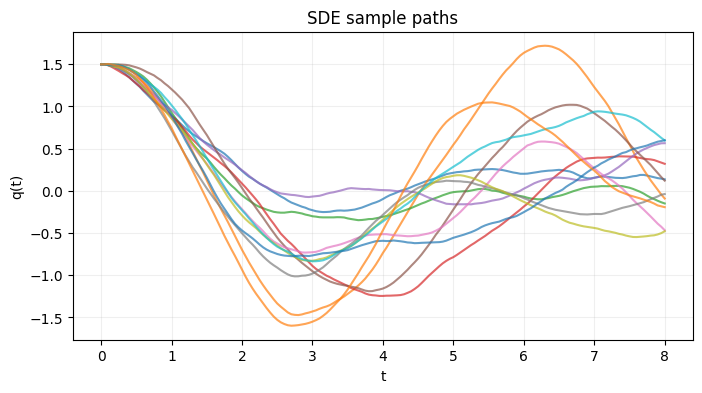

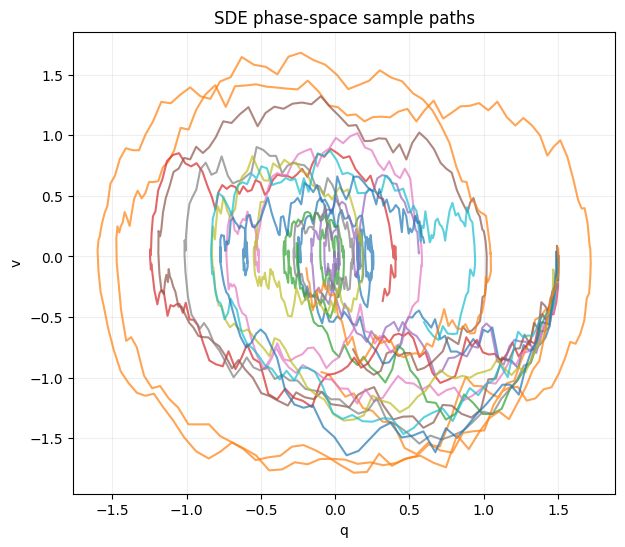

In [3]:
batch_size = 12
initial_states = initial_state.repeat(batch_size, 1)

reference_paths, reference_noise = make_sde_reference_dataset(
    initial_states=initial_states,
    times=times,
    config=config,
    seed=0,
)

plot_sample_paths(times, reference_paths)
plot_phase_samples(reference_paths)


## 3. Fokker–Planck PINN

이 예제의 SDE는 선형이고 초기분포를 Gaussian으로 두므로, Fokker–Planck 방정식의 해도 Gaussian으로 유지됩니다. 따라서 확률밀도
$\rho:[0,T]\times\mathbb{R}^2\to\mathbb{R}_{\ge0}$를 임의의 함수로 직접 학습하지 않고, 평균 $\mu(t)\in\mathbb{R}^2$와 공분산 $\Sigma(t)\in\mathbb{R}^{2\times2}$를 PINN으로 학습합니다.

Fokker–Planck PDE가 주는 moment dynamics는

$$
\frac{d\mu}{dt}=A\mu,
$$

$$
\frac{d\Sigma}{dt}=A\Sigma+\Sigma A^\top+BB^\top
$$

입니다.

초기 평균과 공분산은 모델 구조에 정확히 고정하고, $\Sigma(t)$는 Cholesky factor로 만들기 때문에 항상 positive definite입니다. 그 결과 Gaussian density는 모든 시간에서 자동으로 정규화되어 이전처럼 $\rho\approx0$으로 붕괴할 수 없습니다.



In [ ]:
from rl_tmp.sde_methods.fpe_pinn import train_fpe_pinn

fpe_result = train_fpe_pinn(
    initial_mean=initial_state,
    initial_std=0.20,
    config=config,
    t_final=t_final,
    steps=2500,
    collocation_points=128,
    seed=0,
    device=device,
)

plot_loss(
    fpe_result.history,
    title="Gaussian Fokker-Planck PINN residual",
    log_scale=True,
)

with torch.no_grad():
    mean_0, covariance_0 = fpe_result.model.moments(
        torch.tensor([[0.0]], device=device)
    )
    mean_T, covariance_T = fpe_result.model.moments(
        torch.tensor([[t_final]], device=device)
    )

print("initial mean:", mean_0.cpu().squeeze(0))
print("initial covariance:")
print(covariance_0.cpu().squeeze(0))
print("final mean:", mean_T.cpu().squeeze(0))
print("final covariance:")
print(covariance_T.cpu().squeeze(0))
print("final residual loss:", fpe_result.history["total"][-1])

plot_density(
    model=fpe_result.model,
    time=0.0,
    device=device,
    title="Gaussian FPE-PINN density at t=0",
)

plot_density(
    model=fpe_result.model,
    time=t_final,
    device=device,
    title=f"Gaussian FPE-PINN density at t={t_final}",
)



## 4. Neural SDE

Neural SDE는 drift $b_\theta:\mathbb{R}^2\to\mathbb{R}^2$와 diagonal diffusion $\sigma_\theta:\mathbb{R}^2\to\mathbb{R}^2$를 신경망으로 둡니다.

$$
dX_t=b_\theta(X_t)\,dt+\sigma_\theta(X_t)\odot dW_t.
$$

여기서는 정답 SDE와 같은 noise increment를 사용해 경로 차이를 직접 최소화합니다. 이렇게 하면 이번 작은 학습 예제에서는 drift와 diffusion이 trajectory 차이에 어떻게 영향을 주는지 바로 볼 수 있습니다.


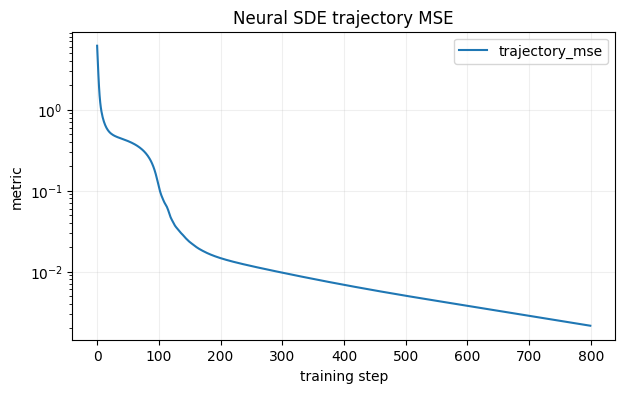

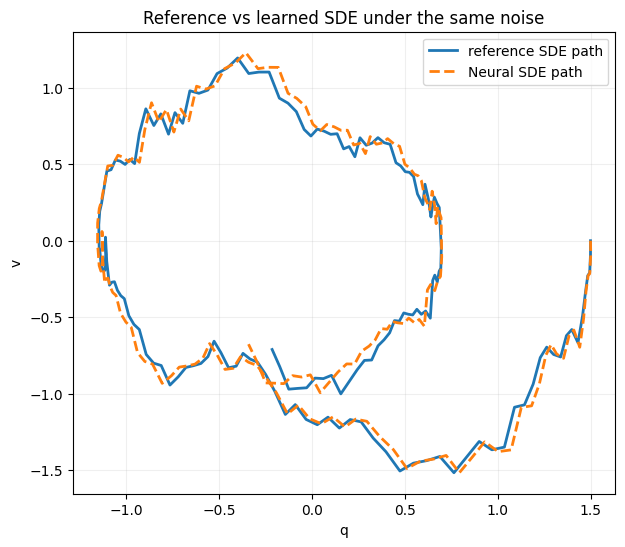

In [5]:
from rl_tmp.sde_methods.neural_sde import predict_neural_sde, train_neural_sde

train_batch = 32
train_initial_states = initial_state.repeat(train_batch, 1)

train_paths, train_noise = make_sde_reference_dataset(
    initial_states=train_initial_states,
    times=times,
    config=config,
    seed=1,
)

neural_sde_result = train_neural_sde(
    initial_states=train_initial_states,
    times=times,
    target_trajectories=train_paths,
    noise_increments=train_noise,
    steps=800,
    seed=0,
    device=device,
)

plot_loss(
    neural_sde_result.history,
    title="Neural SDE trajectory MSE",
    log_scale=True,
)

test_path, test_noise = make_sde_reference_dataset(
    initial_states=initial_state.unsqueeze(0),
    times=times,
    config=config,
    seed=123,
)

learned_path = predict_neural_sde(
    model=neural_sde_result.model,
    initial_state=initial_state.unsqueeze(0),
    times=times,
    noise_increments=test_noise,
    device=device,
)

plot_neural_sde_comparison(
    reference=test_path[:, 0],
    prediction=learned_path[:, 0],
)


## 5. RL control under SDE noise

RL에서는 acceleration 방향에 제어입력 $u_t\in\mathbb{R}$를 추가합니다.

$$
dv_t=(-kq_t-cv_t+u_t)\,dt+\sigma\,dW_t.
$$

정책은 상태 $x_t\in\mathbb{R}^2$를 받아 action distribution을 만드는 map입니다.

$$
\pi_\theta:\mathbb{R}^2\to\mathcal{P}(\mathbb{R}).
$$

기존처럼 한 episode씩 REINFORCE를 업데이트하면 SDE noise 때문에 gradient variance가 커져 후반에 policy collapse가 발생했습니다. 여기서는 여러 stochastic rollout을 한 batch로 묶고, 같은 time step의 batch return 평균을 baseline으로 사용해 advantage를 만든 뒤 gradient clipping을 적용합니다.



In [ ]:
from rl_tmp.sde_methods.sde_rl import rollout_sde_policy, train_sde_reinforce

goal_state = torch.tensor([0.0, 0.0], dtype=torch.float32)

rl_result = train_sde_reinforce(
    initial_state=initial_state,
    goal_state=goal_state,
    config=config,
    t_final=t_final,
    dt=dt,
    episodes=8000,
    batch_size=32,
    seed=0,
    device=device,
)

plot_loss(
    rl_result.history,
    title="Batched SDE REINFORCE mean episode return",
)

rollout_times, controlled_states, actions = rollout_sde_policy(
    policy=rl_result.policy,
    initial_state=initial_state,
    config=config,
    t_final=t_final,
    dt=dt,
    max_action=3.0,
    seed=999,
    device=device,
)

generator = torch.Generator()
generator.manual_seed(999)

uncontrolled_states = solve_sde_reference(
    initial_state=initial_state,
    times=rollout_times,
    config=config,
    generator=generator,
)

print(
    "best batch mean return:",
    max(rl_result.history["mean_episode_return"]),
)
print(
    "final state distance to goal:",
    torch.linalg.vector_norm(
        controlled_states[-1] - goal_state
    ).item(),
)

plot_sde_rl_rollout(
    uncontrolled=uncontrolled_states,
    controlled=controlled_states,
    goal_state=goal_state,
    actions=actions,
    times=rollout_times,
)



## 결과를 볼 때

- Euler–Maruyama: 같은 초기 상태에서도 샘플 경로가 퍼지는지 확인
- FPE-PINN: 시간에 따라 확률밀도가 이동하고 퍼지는지 확인
- Neural SDE: 같은 noise를 넣었을 때 학습된 SDE가 reference path를 따라가는지 확인
- RL: noise가 있는 상태에서도 정책 rollout이 goal 쪽으로 상태를 제어하는지 확인
